<a href="https://colab.research.google.com/github/layan3254/Deep_learning/blob/main/Amazon_Reviews_Prodect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Summary: Amazon Fine Food Reviews Sentiment Analysis
## Dataset Overview
The dataset consists of reviews of fine foods from Amazon. It includes user information, product ratings, and plaintext reviews. In this project, we focused on:

- **Target**: Predicting user satisfaction (Positive vs. Negative) based on the Score column.

- **Size**: A sampled subset of 5,000 records to ensure efficient processing and high-quality feature extraction.

In [ ]:
# Since I dealing with text which may vary in length or require special processing,
# PyTorch allows you to easily modify the model's behavior during training.

In [ ]:
import os, pandas as pd, numpy as np, kagglehub
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Data Understanding

In [ ]:
# data
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
df = pd.read_csv(os.path.join(path, "Reviews.csv"))


100%|██████████| 242M/242M [00:08<00:00, 29.1MB/s]

Extracting files...


In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df.shape

(568454, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [ ]:
# Selecting  features
df = df[["UserId", "ProductId", "Score", "Summary", "Text"]].dropna()
df = df.sample(5000, random_state=42).reset_index(drop=True)

In [ ]:
df.head()

,UserId,ProductId,Score,Summary,Text
0,A16O0S1QROXGJM,B0088YBUOU,4,I like these!,These are actually very tasty. Pure potatoes ...
1,A37V5C3TXIBIHT,B000Q75354,4,Good but subjectively not 5 star,I realize that taste is a matter of personal p...
2,A28NR6KKJGHQXH,B000EOXQS0,5,"Lipton Cup A Soup, Spring Vegetable.4 oz",This is one of my Favorite cup of soup choices...
3,AJBVY9K7D1AZ4,B0000D9589,4,"Suited to its purpose, if not quite its goal...",If you like the classic taste of a good margar...
4,A2G8OM5IXSG97Q,B000UPNK9S,2,Tastes artificial!,I was willing to give this a chance even after...


In [ ]:
# target and text
# Preparing target labels and combined text feature
# Label 1 for positive (Score >= 4), Label 0 for negative
df["label"] = (df["Score"] >= 4).astype(int)
df["review_text"] = df["Summary"] + " " + df["Text"]

In [ ]:
df.head()

,UserId,ProductId,Score,Summary,Text,label,review_text
0,A16O0S1QROXGJM,B0088YBUOU,4,I like these!,These are actually very tasty. Pure potatoes ...,1,I like these! These are actually very tasty. ...
1,A37V5C3TXIBIHT,B000Q75354,4,Good but subjectively not 5 star,I realize that taste is a matter of personal p...,1,Good but subjectively not 5 star I realize tha...
2,A28NR6KKJGHQXH,B000EOXQS0,5,"Lipton Cup A Soup, Spring Vegetable.4 oz",This is one of my Favorite cup of soup choices...,1,"Lipton Cup A Soup, Spring Vegetable.4 oz This ..."
3,AJBVY9K7D1AZ4,B0000D9589,4,"Suited to its purpose, if not quite its goal...",If you like the classic taste of a good margar...,1,"Suited to its purpose, if not quite its goal....."
4,A2G8OM5IXSG97Q,B000UPNK9S,2,Tastes artificial!,I was willing to give this a chance even after...,0,Tastes artificial! I was willing to give this ...


# Feature Engineering

In [ ]:
# Feature Engineering
df['user_avg_score'] = df.groupby('UserId')['Score'].transform('mean')
df['product_avg_score'] = df.groupby('ProductId')['Score'].transform('mean')

df['text_len'] = df['review_text'].str.len()

In [ ]:
# # Text Vectorization using TF-IDF with Unigrams and Bigrams
# Term Frequency-Inverse Document Frequency
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words="english")
X_text = tfidf.fit_transform(df["review_text"]).toarray()

In [ ]:
# Concatenating all features: (Text + User + Product)
#X = np.hstack((X_text, df[['user_idx', 'item_idx']].values))
#y = df["label"].values

X_meta = df[['user_avg_score', 'product_avg_score', 'text_len']].values
X = np.hstack((X_text, X_meta))
y = df["label"].values

In [ ]:
# Scaling
# Standardizing features for model stability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Model

In [ ]:
# Split into Training (70%) and Temporary (30%)
x_train, x_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
# # Split Temporary set into Validation and Test (15% each)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# Baseline Model (Logistic Regression)
baseline = LogisticRegression(max_iter=1000)
baseline.fit(x_train, y_train)
baseline_preds = baseline.predict(x_test)
baseline_acc = accuracy_score(y_test, baseline_preds)

print(f"\n[INFO] Baseline Accuracy: {baseline_acc:.4f}")
print(classification_report(y_test, baseline_preds))


[INFO] Baseline Accuracy: 0.9640
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       156
           1       0.97      0.98      0.98       594

    accuracy                           0.96       750
   macro avg       0.95      0.94      0.94       750
weighted avg       0.96      0.96      0.96       750



In [ ]:
# Deep Learning Model
final_model = keras.Sequential([
    layers.Dense(256, activation="relu", input_shape=(x_train.shape[1],),
                 kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile final model
# Compiling the model with Sparse Categorical Crossentropy
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
final_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       257,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,617 (1.13 MB)

 Trainable params: 294,849 (1.12 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# Callbacks
# Configuring Callbacks for optimization
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [ ]:

# Training the model with validation monitoring

final_history = final_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    ],
    verbose=1
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8303 - loss: 0.7733 - val_accuracy: 0.9067 - val_loss: 0.6253 - learning_rate: 0.0010
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9620 - loss: 0.4757 - val_accuracy: 0.9253 - val_loss: 0.5250 - learning_rate: 0.0010
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9771 - loss: 0.3976 - val_accuracy: 0.9307 - val_loss: 0.4939 - learning_rate: 0.0010
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9914 - loss: 0.3425 - val_accuracy: 0.9320 - val_loss: 0.4783 - learning_rate: 0.0010
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9897 - loss: 0.3063 - val_accuracy: 0.9413 - val_loss: 0.4436 - learning_rate: 0.0010
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9894 - loss: 0.2868 - val_accuracy: 0.9387 - val_loss: 0.4252 - learning_rate: 0.0010
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9906 - loss: 0.2663

In [ ]:
# Evaluating on the unseen test set
test_loss, deep_acc = final_model.evaluate(x_test, y_test, verbose=0)

y_deep_probs = final_model.predict(x_test)
y_deep_preds = (y_deep_probs > 0.5).astype(int)

print(f"\n[RESULT] Final Deep Learning Accuracy: {deep_acc:.4f}")
print("\nDetailed Classification Report for Deep Learning:")
print(classification_report(y_test, y_deep_preds))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

[RESULT] Final Deep Learning Accuracy: 0.9520

Detailed Classification Report for Deep Learning:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       156
           1       0.97      0.97      0.97       594

    accuracy                           0.95       750
   macro avg       0.93      0.93      0.93       750
weighted avg       0.95      0.95      0.95       750



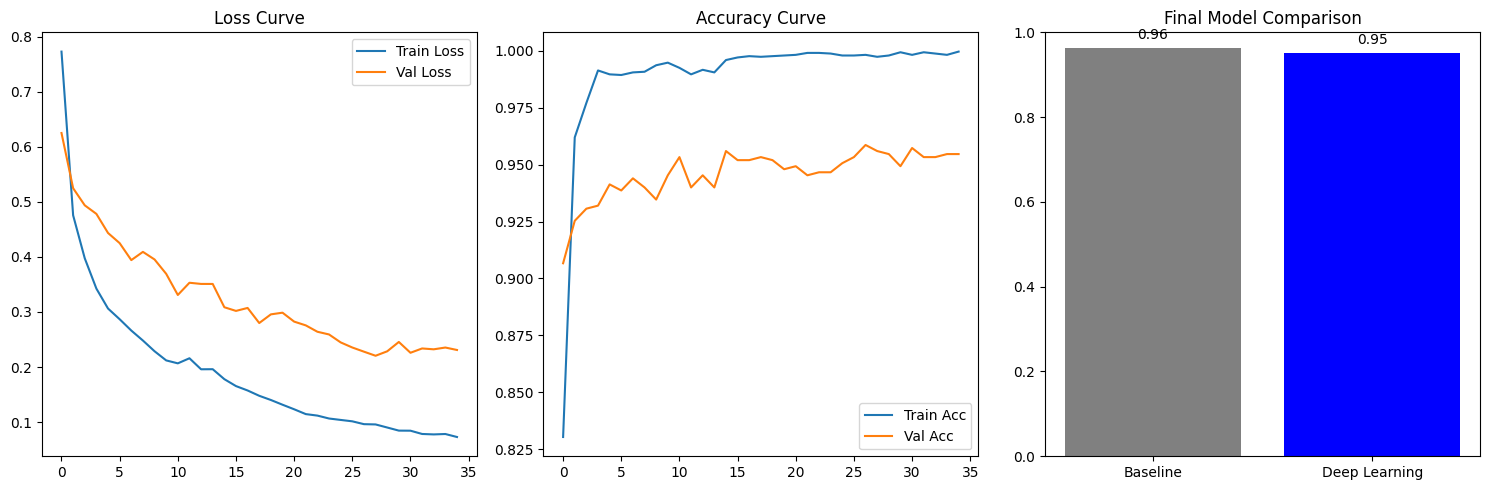

In [ ]:
# Plotting Loss and Accuracy curves for analysis
plt.figure(figsize=(15, 5))
# Subplot 1: Loss curves
plt.subplot(1, 3, 1)
plt.plot(final_history.history['loss'], label='Train Loss')
plt.plot(final_history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

# Subplot 2: Accuracy curves
plt.subplot(1, 3, 2)
plt.plot(final_history.history['accuracy'], label='Train Acc')
plt.plot(final_history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()

# Subplot 3: Baseline vs Deep Learning Comparison
plt.subplot(1, 3, 3)
plt.bar(['Baseline', 'Deep Learning'], [baseline_acc, deep_acc], color=['gray', 'blue'])
plt.title('Final Model Comparison')
plt.ylim(0, 1.0)
for i, v in enumerate([baseline_acc, deep_acc]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# Function to predict sentiment for a new, unseen review
def predict_new_review(review_text, user_avg=4.0, prod_avg=4.0):
    # 1. Prepare input text (Wrapped in a list for the vectorizer)
    combined_text = [review_text]

    # 2. Transform text using the pre-trained TF-IDF vectorizer
    # Note: We use .transform(), NOT .fit_transform() to maintain consistency
    text_features = tfidf.transform(combined_text).toarray()

    # 3. Extract metadata features (Text length and provided averages)
    text_len = len(review_text)
    meta_features = np.array([[user_avg, prod_avg, text_len]])

    # 4. Feature Fusion: Combine text features with metadata (Numerical)
    final_features = np.hstack((text_features, meta_features))

    # 5. Apply the same scaling transformation used during training
    final_features_scaled = scaler.transform(final_features)

    # 6. Perform Inference: Generate probability score from the model
    prediction_prob = final_model.predict(final_features_scaled, verbose=0)[0][0]

    # 7. Classification: Map probability to a binary label based on 0.5 threshold
    label = 'Positive (Liked)' if prediction_prob > 0.5 else 'Negative (Not Liked)'

    # Output formatting
    print(f"Review: {review_text}")
    print(f"Probability: {prediction_prob:.4f}")
    print(f"Predicted Label: {label}")
    print("-" * 30)

# Testing the model with sample reviews
predict_new_review("Terrible quality, broke after one day. Very disappointed.")
predict_new_review("Absolutely amazing! The taste is great and the shipping was fast.")

Review: Terrible quality, broke after one day. Very disappointed.
Probability: 0.0077
Predicted Label: Negative (Not Liked)
------------------------------
Review: Absolutely amazing! The taste is great and the shipping was fast.
Probability: 0.9931
Predicted Label: Positive (Liked)
------------------------------


In [ ]:
# --- Test with Old English / Rare Words ---

# Words like 'Thou' (you), 'hath' (has), 'art' (are), 'betwixt' (between)
old_english_review = "Thou art a merchant of most excellent goods, thy food hath no peer betwixt the seas!"

print("Testing with Old English / Rare Words Context:")
predict_new_review(old_english_review)

# Let's try a very negative one with old words
negative_old_review = "Alas! The quality is naught but woe, a scurvy product indeed."
predict_new_review(negative_old_review)

Testing with Old English / Rare Words Context:
Review: Thou art a merchant of most excellent goods, thy food hath no peer betwixt the seas!
Probability: 1.0000
Predicted Label: Positive (Liked)
------------------------------
Review: Alas! The quality is naught but woe, a scurvy product indeed.
Probability: 0.9337
Predicted Label: Positive (Liked)
------------------------------
